In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline


In [2]:
# Read data
df1 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data2_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data3_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")
df4 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data4_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data5_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data6_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [3]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [4]:

# save dataframes into list
DF = [df1, df2, df3, df4, df5, df6]

# remove column name spaces of each DataFrame 
for df in DF:
    remove_spaces(df)
    
    

In [5]:
# Selects a feature from the data. Creates df with Stations as columns.
# Takes in list of dataframes and the selected feature as a string. 
def select_feature(DF, feature):
    df_feature = pd.concat(DF, axis=1)[feature]
    df_feature.columns = [str(f"Station{i}") for i in range(1, len(DF)+1)]
    return df_feature

In [6]:
# create df with only Air temp data of each Station
df_Tair = select_feature(DF, "Tair")



In [7]:
# Exclude data with dates before 2015
reindex_df_Tair = df_Tair[(df_Tair.index > "2014-12-31 23:00")]

In [8]:
# Fill nan values
reindex_df_Tair.replace([np.inf, -np.inf], np.nan, inplace=True)
reindex_df_Tair.fillna(reindex_df_Tair.mean(), inplace=True)

reindex_df_Tair

,Station1,Station2,Station3,Station4,Station5,Station6
Date,,,,,,
2015-01-01 00:00:00,-1.090,-1.155000,-0.547000,-2.493,-0.632000,-1.013
2015-01-01 01:00:00,-1.038,-1.188500,-0.440000,-2.295,-1.188500,-0.981
2015-01-01 02:00:00,-0.981,-1.312333,-1.312333,-2.046,-1.312333,-0.910
2015-01-01 03:00:00,-0.814,-0.891000,-0.891000,-1.580,-0.328000,-0.842
2015-01-01 04:00:00,-0.805,-0.833250,-0.833250,-1.432,-0.311000,-0.785
...,...,...,...,...,...,...
2021-08-31 20:00:00,29.100,18.833463,28.240000,29.940,29.810000,31.410
2021-08-31 21:00:00,29.595,18.833463,29.595000,28.880,29.595000,30.310
2021-08-31 22:00:00,27.730,18.833463,24.940000,28.190,27.770000,29.990


In [9]:
update_df_Tair = reindex_df_Tair.loc["2015"].resample('M').mean()

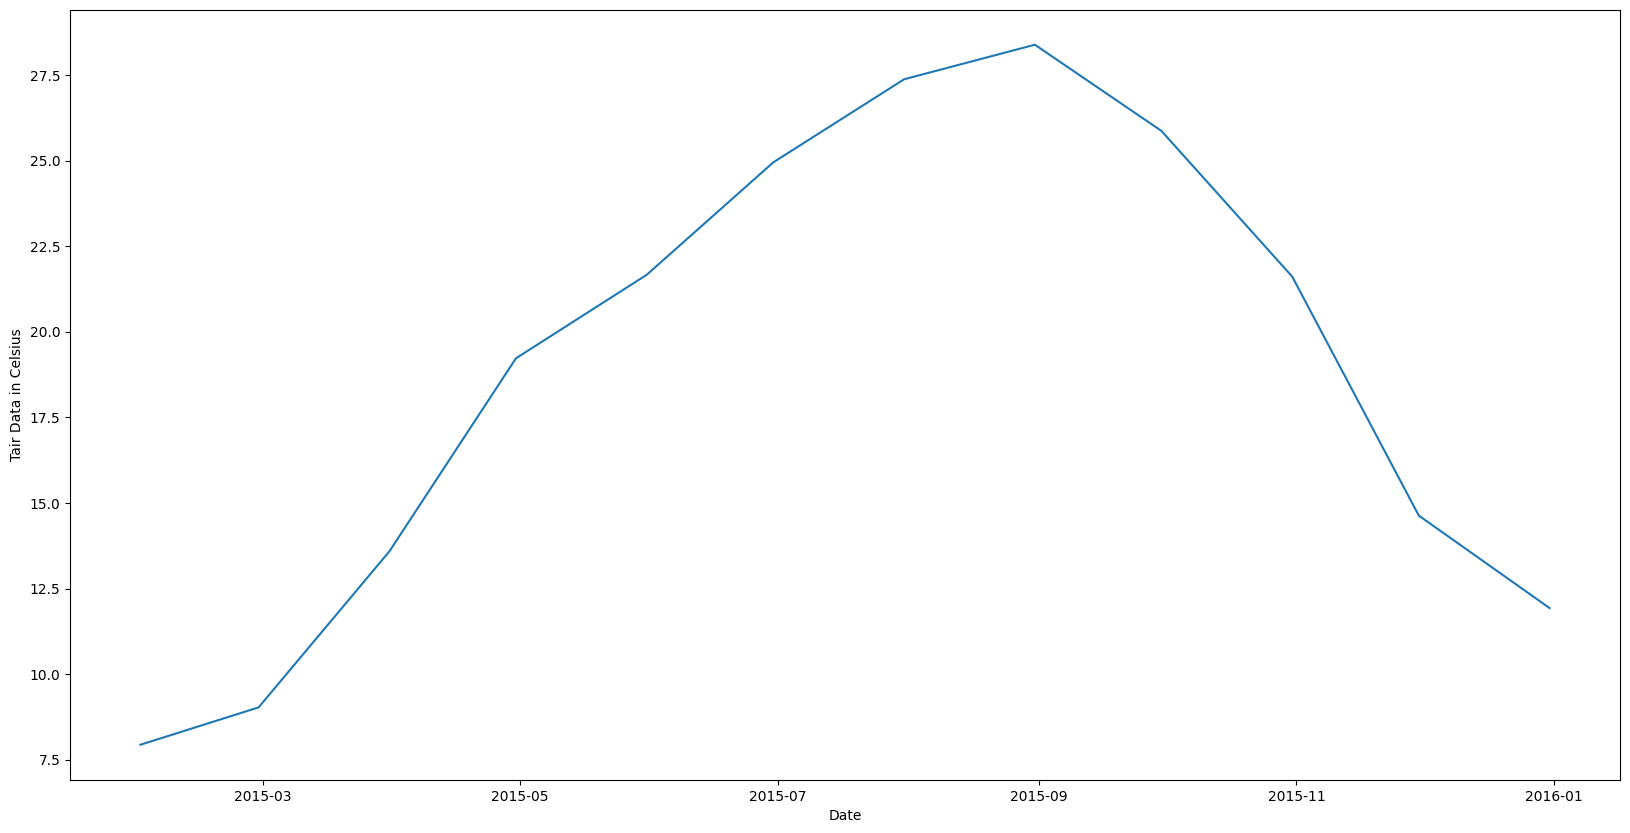

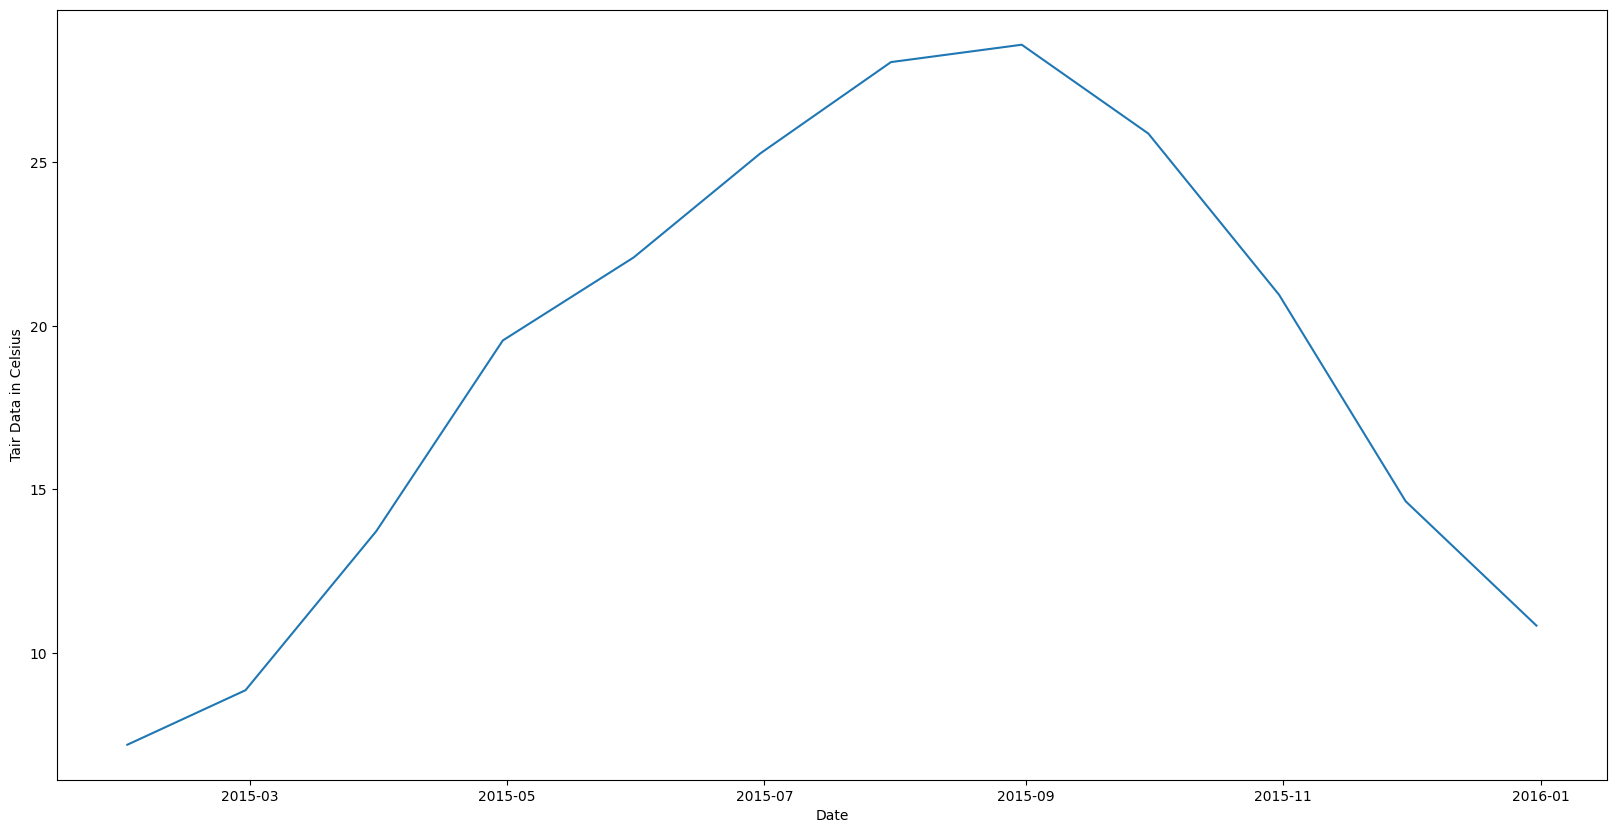

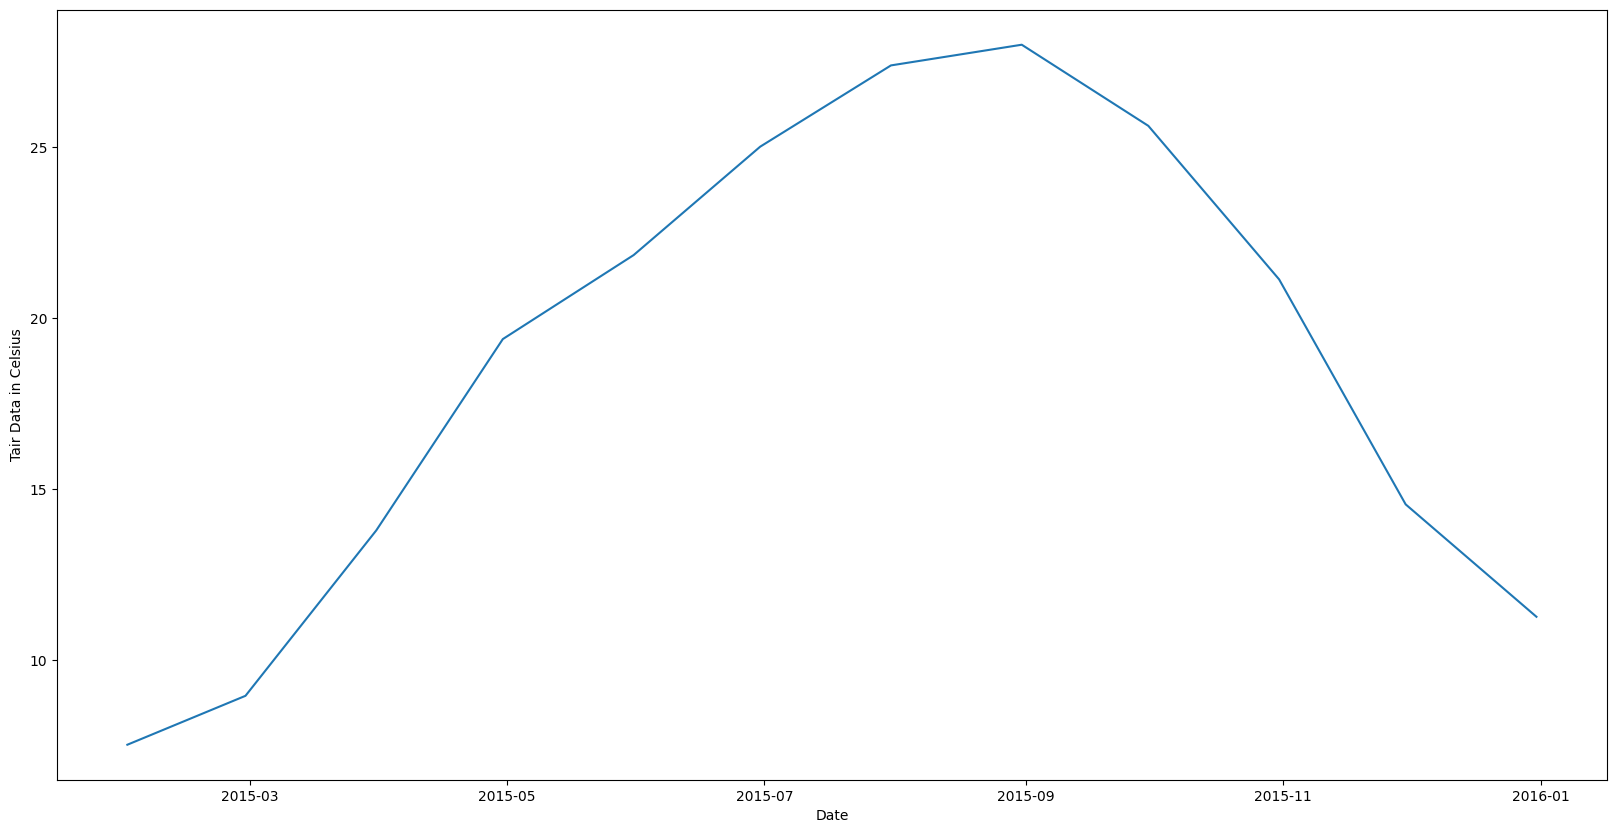

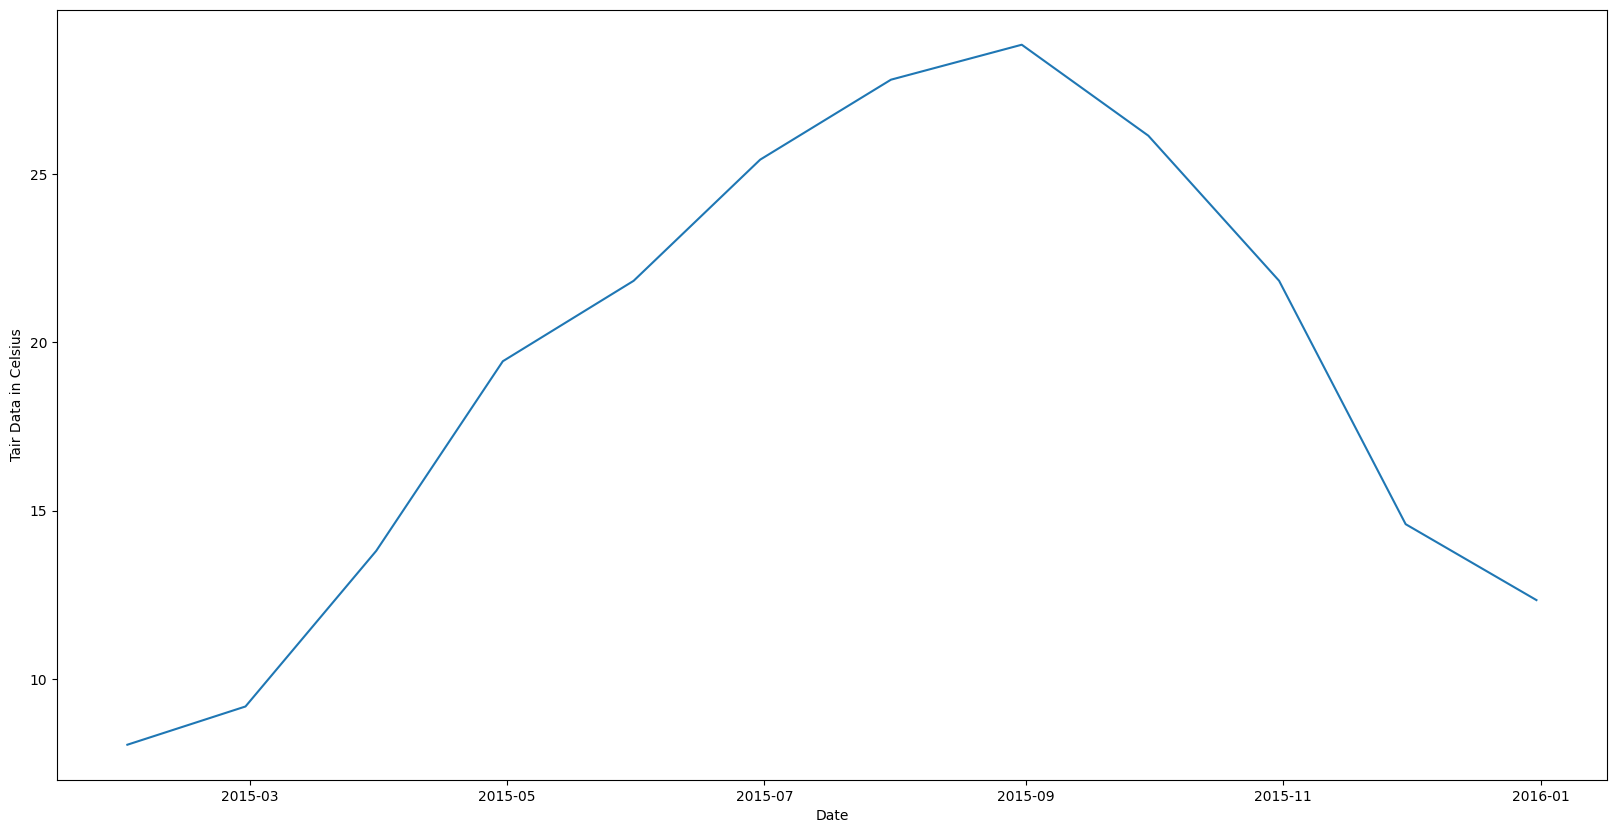

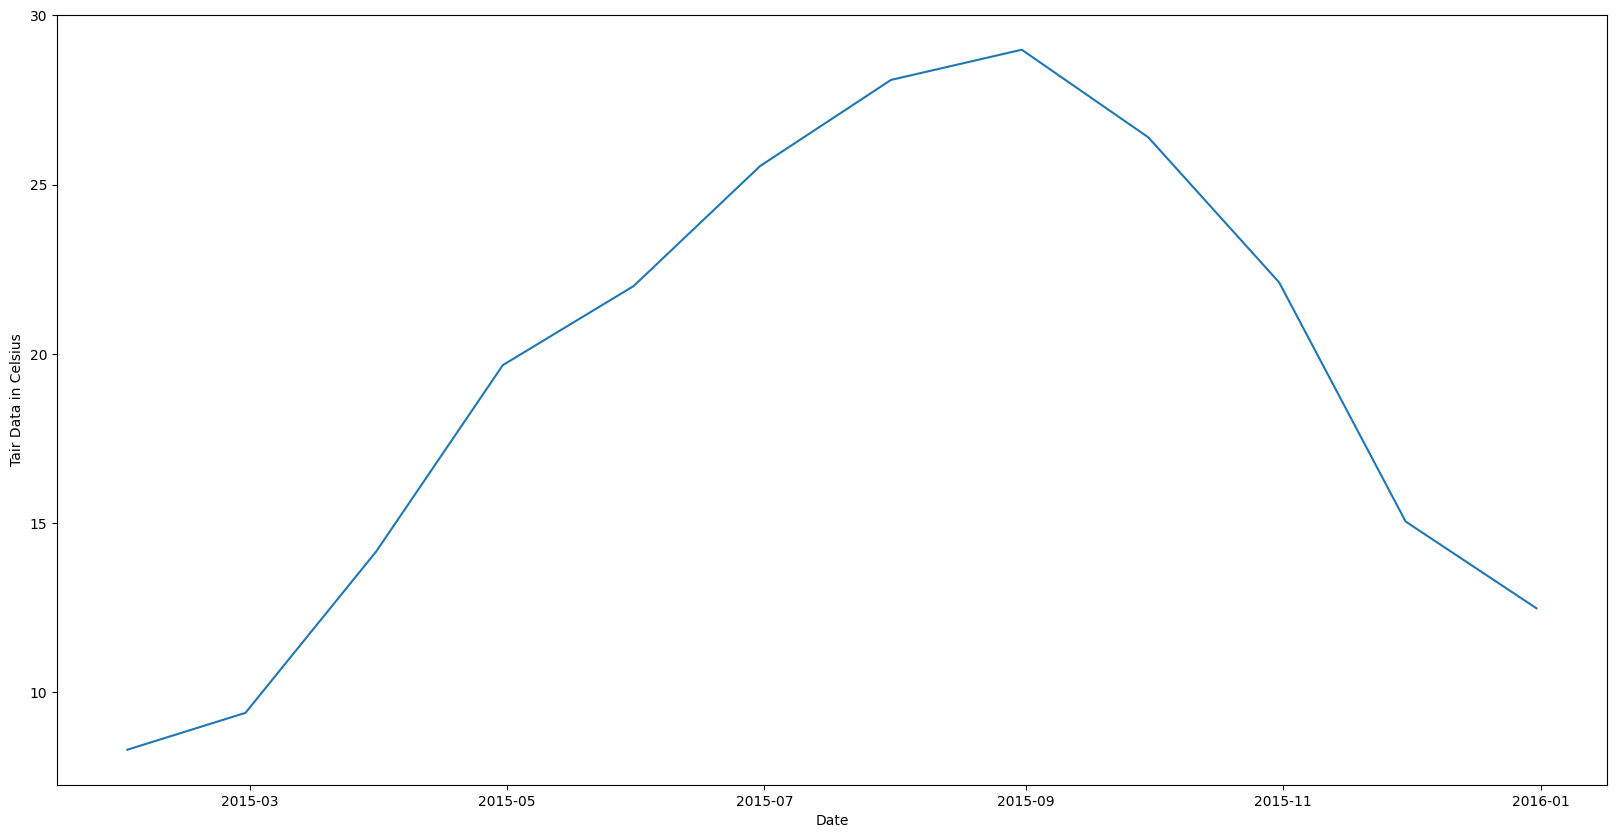

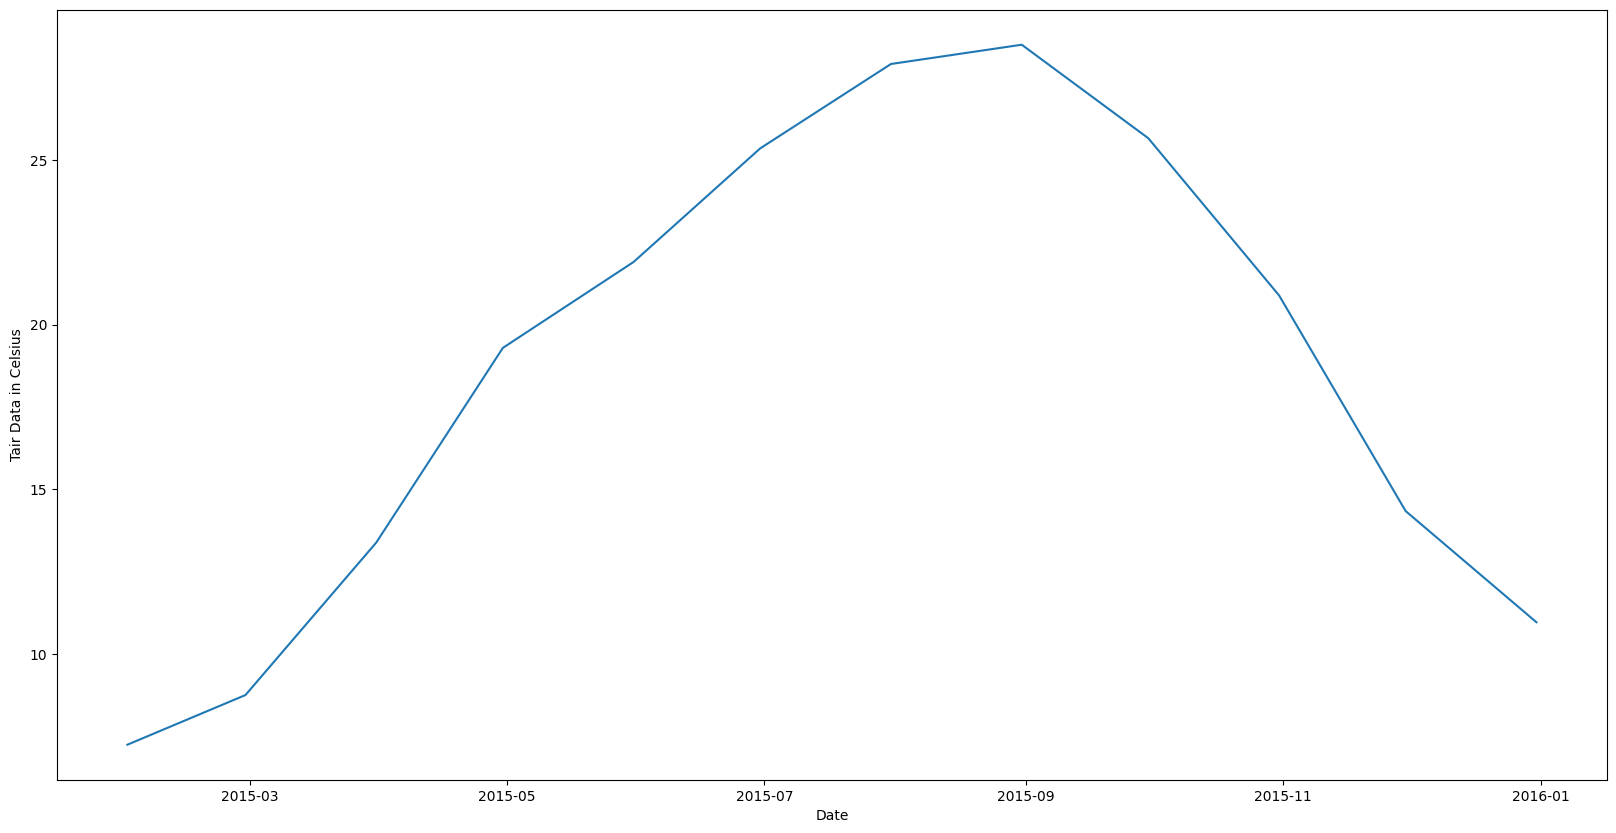

In [10]:
stations = [update_df_Tair.Station1, update_df_Tair.Station2, update_df_Tair.Station3, update_df_Tair.Station4, update_df_Tair.Station5, update_df_Tair.Station6]
# visualize station 1 data
for station in stations:
    fig, ax = plt.subplots()

    ax.plot(station)
    ax.set_xlabel('Date')
    ax.set_ylabel('Tair Data in Celsius')

    

In [11]:
# stationarity test for stations
for station in stations:
    ad_fuller_result = adfuller(station)

    print(f'ADF Statistic: {ad_fuller_result[0]}')
    print(f'p-value: {ad_fuller_result[1]}\n')

ADF Statistic: -3.2989741487898447
p-value: 0.014924392390222394

ADF Statistic: -3.694993709074149
p-value: 0.004184125706431452

ADF Statistic: -3.5504771836699596
p-value: 0.0067815123673427725

ADF Statistic: -1.4498518025568863
p-value: 0.5581572131016266

ADF Statistic: -3.2559653119823833
p-value: 0.016965291530502642

ADF Statistic: -3.6199533308585714
p-value: 0.0053908229276280325



In [12]:
train_list=[]
test_list=[]

# Train/Test Split
for station in stations:
    train_list.append(station[:'2015-10-17 23:00'])
    test_list.append(station['2015-10-17 23:00':])

In [13]:
# Defining optimize_SARIMAX function
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int)->pd.DataFrame:

    results=[]
    
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        
        results.append([order, model.aic])
    
    result_df=pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [14]:
# Define range of values for p, q, P, and Q

ps= range(0, 5, 1)
qs= range(0, 5, 1)
Ps= range(0, 5, 1)
Qs= range(0, 5, 1)

# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))

# Set constants
d=0
D=0
s=12

In [ ]:
SARIMA_result_df_list=[]

# Find the (p, d, q) (P, D, Q)m comination with the lowest AIC
for i, train in enumerate(train_list):
    SARIMA_result_df_list.append(optimize_SARIMAX(train, None, order_list, d, D, s))

  0%|          | 0/625 [00:00<?, ?it/s]

In [ ]:
optimal_parameters=[]
for i, station in enumerate(SARIMA_result_df_list):
    result_array=station.to_numpy()
    optimal_parameters.append(result_array[0])
    print(result_array)

In [ ]:
SARIMA_model_fit_array=[]
# Fit optimal model to study its residuals
for i, train in enumerate(train_list):
    SARIMA_model = SARIMAX(train, order=(result_array[i][0][0], 0, result_array[i][0][1]), seasonal_order = (result_array[i][0][2], 0, result_array[0][0][3], 12), enforce_invertibility=False)
    SARIMA_model_fit_array.append(SARIMA_model.fit(disp=False))
    print(SARIMA_model_fit_array[i].summary())

In [ ]:
# Plot residual's diagnostics
for model in SARIMA_model_fit_array:
    model.plot_diagnostics(figsize=(10,8)) 

In [ ]:
lbvalues = []
pvalues = []

# Run the Ljung-Box test
for model in SARIMA_model_fit_array:
    residuals = model.resid
    lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 3, 1))

    lbvalues.append(lbvalue)
    pvalues.append(pvalue)
    
    # Print p-values
    print(pvalue)


In [ ]:
# Function to preform rolling forcasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season=[]
        
        for n, i in enumerate(range(train_len, total_len, window)):
            last_season = stations[n][i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for n, i in enumerate(range(train_len, total_len, window)):
            model = SARIMAX(stations[n][:i], order=(VALUES), seasonal_order = (VALUES))
            res = model.fit(disp=False)
            predictions = res.get_predictions(0, i + window -1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        
        return pred_SARIMA

In [ ]:
pred_df_array=[]
for station in stations:
    pred_df_array.append(station['2015-12-31 23:00':])

In [ ]:
# Define length of training set, horizon of forecast, and the window of forecast
TRAIN_LEN = 9
HORIZON = 3
WINDOW = 1



for i, station in enumerate(stations):
    # Preform rolling forecast with the naive seasonal baseline
    print(rolling_forecast(station, TRAIN_LEN, HORIZON, WINDOW, 'last_season'))

#Display the predictions
# print(pred_df_array)